C:\Users\Thejan\AppData\Local\Temp\ipykernel_21748\3891884995.py:58: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_21748\3891884995.py:58: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_21748\3891884995.py:58: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_21748\3891884995.py:58: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path

Epoch 1/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 853s 2ms/step - accuracy: 0.9823 - loss: 0.0643 - val_accuracy: 0.9838 - val_loss: 0.0556
Epoch 2/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 839s 2ms/step - accuracy: 0.9838 - loss: 0.0585 - val_accuracy: 0.9849 - val_loss: 0.0537
Epoch 3/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 846s 2ms/step - accuracy: 0.9839 - loss: 0.0581 - val_accuracy: 0.9837 - val_loss: 0.0547
Epoch 4/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 821s 2ms/step - accuracy: 0.9839 - loss: 0.0579 - val_accuracy: 0.9849 - val_loss: 0.0530
Epoch 5/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 781s 2ms/step - accuracy: 0.9840 - loss: 0.0578 - val_accuracy: 0.9850 - val_loss: 0.0543
Epoch 6/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 786s 2ms/step - accuracy: 0.9841 - loss: 0.0577 - val_accuracy: 0.9853 - val_loss: 0.0525
Epoch 7/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 784s 2ms/step - accuracy: 0.9841 - loss: 0.0577 - val_accuracy: 0.9851 - val_loss: 0.0533
Epoch 8/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 75

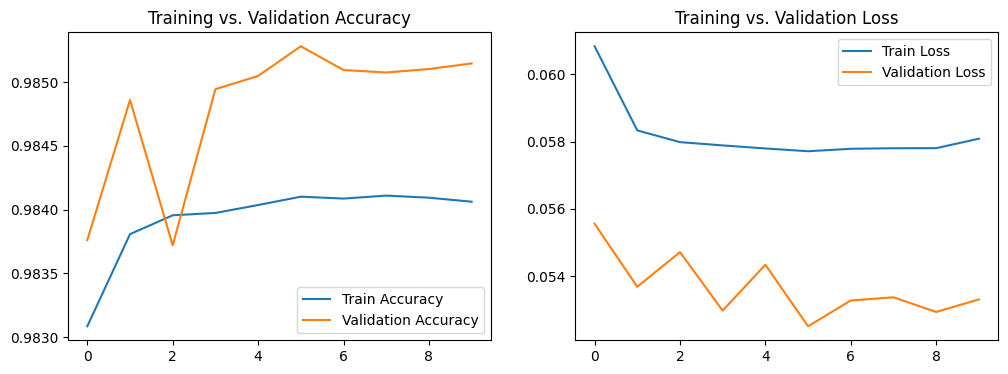

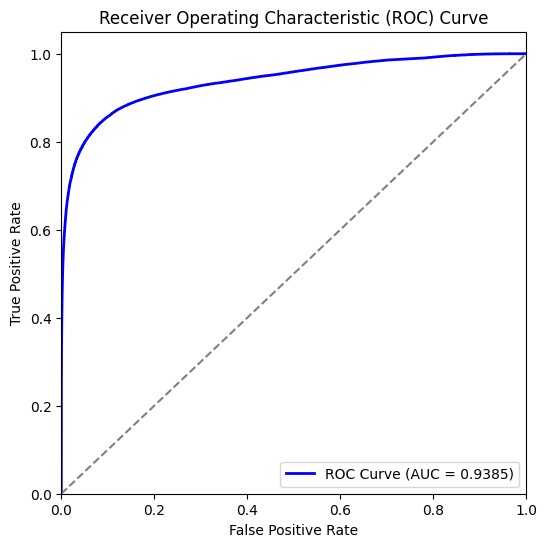

In [2]:
import os
import numpy as np
import mne
import tensorflow as tf
from scipy.signal import butter, filtfilt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc

# Define paths
data_root = r"C:\sem 2 thejan\Paper\edf\seizure file"
summary_file = os.path.join(data_root, "all_summaries.txt")

# Butterworth Bandpass Filter
def butter_bandpass_filter(data, lowcut=0.5, highcut=50.0, fs=256, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=1)

# Parse seizure information
def parse_summary(file_path):
    seizure_info = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    file_name = None
    for line in lines:
        line = line.strip()
        if line.startswith("File Name:"):
            file_name = line.split()[-1]
            seizure_info[file_name] = []
        if line.startswith("Seizure Start Time:"):
            start_time = int(line.split()[-2])
        if line.startswith("Seizure End Time:"):
            end_time = int(line.split()[-2])
            seizure_info[file_name].append((start_time, end_time))
    return seizure_info

seizure_info = parse_summary(summary_file)

X, y = [], []  # Data and labels

# Identify the most common 23 channels across all files
channel_counts = {}
for patient in os.listdir(data_root):
    patient_path = os.path.join(data_root, patient)
    if not os.path.isdir(patient_path):
        continue
    files = [f for f in os.listdir(patient_path) if f.endswith('.edf')]
    
    for file in files:
        file_path = os.path.join(patient_path, file)
        raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
        for ch in raw.ch_names:
            channel_counts[ch] = channel_counts.get(ch, 0) + 1

# Select the 23 most common channels
sorted_channels = sorted(channel_counts, key=channel_counts.get, reverse=True)
standard_channels = sorted_channels[:23]

# Process EEG data
for patient in os.listdir(data_root):
    patient_path = os.path.join(data_root, patient)
    if not os.path.isdir(patient_path):
        continue
    files = [f for f in os.listdir(patient_path) if f.endswith('.edf')]
    
    for file in files:
        file_path = os.path.join(patient_path, file)
        raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
        
        # Adjust channels: Keep only the most common 23 channels
        available_channels = [ch for ch in raw.ch_names if ch in standard_channels]
        raw.pick_channels(available_channels, ordered=True, verbose=False)
        
        data, times = raw[:]
        fs = int(raw.info['sfreq'])  # Sampling frequency
        
        # Apply Butterworth Filter
        data = butter_bandpass_filter(data, fs=fs)
        
        # Create seizure and normal samples
        if file in seizure_info and seizure_info[file]:
            for start, end in seizure_info[file]:
                seizure_samples = data[:, start * fs: end * fs]
                normal_samples = data[:, :start * fs]  # Non-seizure samples
                
                X.append(seizure_samples.T)
                y.append(np.ones(len(seizure_samples.T)))  # Label as seizure
                
                X.append(normal_samples.T)
                y.append(np.zeros(len(normal_samples.T)))  # Label as normal

# Convert to numpy arrays
X = np.vstack(X)
y = np.concatenate(y)

# Normalize data
X = (X - np.mean(X)) / np.std(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define ANN Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

# Evaluate model
loss, acc = model.evaluate(X_test, y_test)
y_pred_prob = model.predict(X_test)  # Probability scores for ROC-AUC
y_pred = np.round(y_pred_prob)  # Convert probabilities to binary values

# Compute Metrics
conf_matrix = confusion_matrix(y_test, y_pred)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
precision = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1])
false_positive_rate = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
mcc = matthews_corrcoef(y_test, y_pred)

# ROC-AUC Calculation
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Print Results
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"False Positive Rate (per hr): {false_positive_rate:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"AUC Score: {roc_auc:.4f}")

# Print Confusion Matrix & Classification Report
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Training & Validation Accuracy/Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\936150403.py:58: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\936150403.py:58: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\936150403.py:58: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\936150403.py:58: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, pr

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\936150403.py:75: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\936150403.py:75: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


...

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\936150403.py:75: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


c:\sem 2 thejan\Paper\myenv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 1131s 2ms/step - accuracy: 0.9823 - loss: 0.0641 - val_accuracy: 0.9845 - val_loss: 0.0545
Epoch 2/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 1189s 3ms/step - accuracy: 0.9838 - loss: 0.0585 - val_accuracy: 0.9847 - val_loss: 0.0535
Epoch 3/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 968s 2ms/step - accuracy: 0.9839 - loss: 0.0578 - val_accuracy: 0.9847 - val_loss: 0.0543
Epoch 4/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 616s 1ms/step - accuracy: 0.9840 - loss: 0.0576 - val_accuracy: 0.9837 - val_loss: 0.0548
Epoch 5/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 620s 1ms/step - accuracy: 0.9841 - loss: 0.0577 - val_accuracy: 0.9850 - val_loss: 0.0528
Epoch 6/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 622s 1ms/step - accuracy: 0.9840 - loss: 0.0579 - val_accuracy: 0.9853 - val_loss: 0.0526
Epoch 7/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 621s 1ms/step - accuracy: 0.9841 - loss: 0.0578 - val_accuracy: 0.9851 - val_loss: 0.0531
Epoch 8/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 

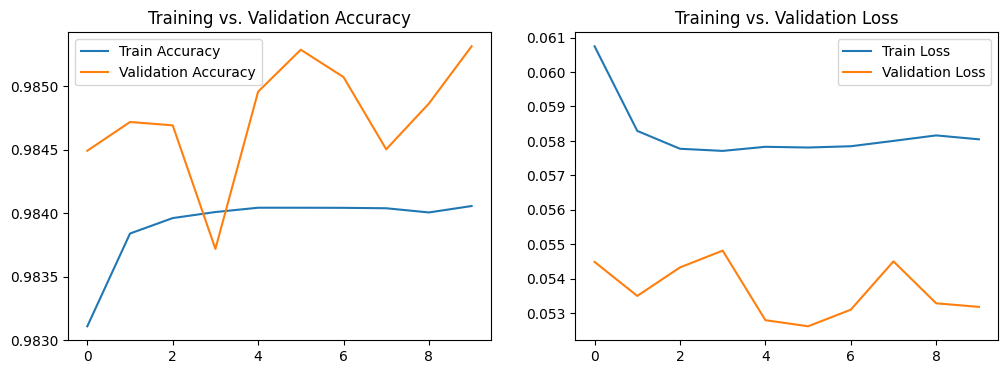

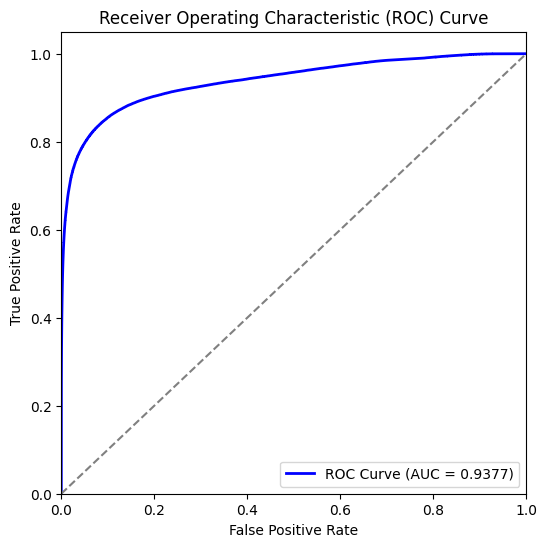

In [1]:
import os
import numpy as np
import mne
import tensorflow as tf
from scipy.signal import butter, filtfilt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc

# Define paths
data_root = r"C:\sem 2 thejan\Paper\edf\seizure file"
summary_file = os.path.join(data_root, "all_summaries.txt")

# Butterworth Bandpass Filter
def butter_bandpass_filter(data, lowcut=0.5, highcut=50.0, fs=256, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=1)

# Parse seizure information
def parse_summary(file_path):
    seizure_info = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    file_name = None
    for line in lines:
        line = line.strip()
        if line.startswith("File Name:"):
            file_name = line.split()[-1]
            seizure_info[file_name] = []
        if line.startswith("Seizure Start Time:"):
            start_time = int(line.split()[-2])
        if line.startswith("Seizure End Time:"):
            end_time = int(line.split()[-2])
            seizure_info[file_name].append((start_time, end_time))
    return seizure_info

seizure_info = parse_summary(summary_file)

X, y = [], []  # Data and labels

# Identify the most common 23 channels across all files
channel_counts = {}
for patient in os.listdir(data_root):
    patient_path = os.path.join(data_root, patient)
    if not os.path.isdir(patient_path):
        continue
    files = [f for f in os.listdir(patient_path) if f.endswith('.edf')]
    
    for file in files:
        file_path = os.path.join(patient_path, file)
        raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
        for ch in raw.ch_names:
            channel_counts[ch] = channel_counts.get(ch, 0) + 1

# Select the 23 most common channels
sorted_channels = sorted(channel_counts, key=channel_counts.get, reverse=True)
standard_channels = sorted_channels[:23]

# Process EEG data
for patient in os.listdir(data_root):
    patient_path = os.path.join(data_root, patient)
    if not os.path.isdir(patient_path):
        continue
    files = [f for f in os.listdir(patient_path) if f.endswith('.edf')]
    
    for file in files:
        file_path = os.path.join(patient_path, file)
        raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
        
        # Drop duplicate channels (keep only the first occurrence of each channel)
        unique_ch_names = []
        ch_indices_to_keep = []
        for i, ch_name in enumerate(raw.ch_names):
            if ch_name not in unique_ch_names:
                unique_ch_names.append(ch_name)
                ch_indices_to_keep.append(i)
        
        # Keep only the unique channels
        raw.pick_channels([raw.ch_names[i] for i in ch_indices_to_keep])
        
        # Adjust channels: Keep only the most common 23 channels
        available_channels = [ch for ch in raw.ch_names if ch in standard_channels]
        raw.pick_channels(available_channels, ordered=True, verbose=False)
        
        data, times = raw[:]
        fs = int(raw.info['sfreq'])  # Sampling frequency
        
        # Apply Butterworth Filter
        data = butter_bandpass_filter(data, fs=fs)
        
        # Create seizure and normal samples
        if file in seizure_info and seizure_info[file]:
            for start, end in seizure_info[file]:
                seizure_samples = data[:, start * fs: end * fs]
                normal_samples = data[:, :start * fs]  # Non-seizure samples
                
                X.append(seizure_samples.T)
                y.append(np.ones(len(seizure_samples.T)))  # Label as seizure
                
                X.append(normal_samples.T)
                y.append(np.zeros(len(normal_samples.T)))  # Label as normal

# Convert to numpy arrays
X = np.vstack(X)
y = np.concatenate(y)

# Normalize data
X = (X - np.mean(X)) / np.std(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define ANN Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

# Evaluate model
loss, acc = model.evaluate(X_test, y_test)
y_pred_prob = model.predict(X_test)  # Probability scores for ROC-AUC
y_pred = np.round(y_pred_prob)  # Convert probabilities to binary values

# Compute Metrics
conf_matrix = confusion_matrix(y_test, y_pred)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
precision = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1])
false_positive_rate = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
mcc = matthews_corrcoef(y_test, y_pred)

# ROC-AUC Calculation
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Print Results
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"False Positive Rate (per hr): {false_positive_rate:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"AUC Score: {roc_auc:.4f}")

# Print Confusion Matrix & Classification Report
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Training & Validation Accuracy/Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\3540971742.py:62: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\3540971742.py:62: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\3540971742.py:62: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\3540971742.py:62: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\3540971742.py:62: Runtime

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy functi

C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\3540971742.py:79: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\3540971742.py:79: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\3540971742.py:79: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


...

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Thejan\AppData\Local\Temp\ipykernel_20644\3540971742.py:79: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy functi

c:\sem 2 thejan\Paper\myenv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 646s 1ms/step - accuracy: 0.9822 - loss: 0.0643 - val_accuracy: 0.9837 - val_loss: 0.0561
Epoch 2/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 877s 2ms/step - accuracy: 0.9838 - loss: 0.0584 - val_accuracy: 0.9850 - val_loss: 0.0533
Epoch 3/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 814s 2ms/step - accuracy: 0.9839 - loss: 0.0584 - val_accuracy: 0.9850 - val_loss: 0.0530
Epoch 4/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 761s 2ms/step - accuracy: 0.9840 - loss: 0.0576 - val_accuracy: 0.9850 - val_loss: 0.0536
Epoch 5/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 680s 1ms/step - accuracy: 0.9840 - loss: 0.0579 - val_accuracy: 0.9853 - val_loss: 0.0522
Epoch 6/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 620s 1ms/step - accuracy: 0.9840 - loss: 0.0579 - val_accuracy: 0.9852 - val_loss: 0.0522
Epoch 7/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 656s 1ms/step - accuracy: 0.9840 - loss: 0.0580 - val_accuracy: 0.9851 - val_loss: 0.0529
Epoch 8/10
473703/473703 ━━━━━━━━━━━━━━━━━━━━ 65

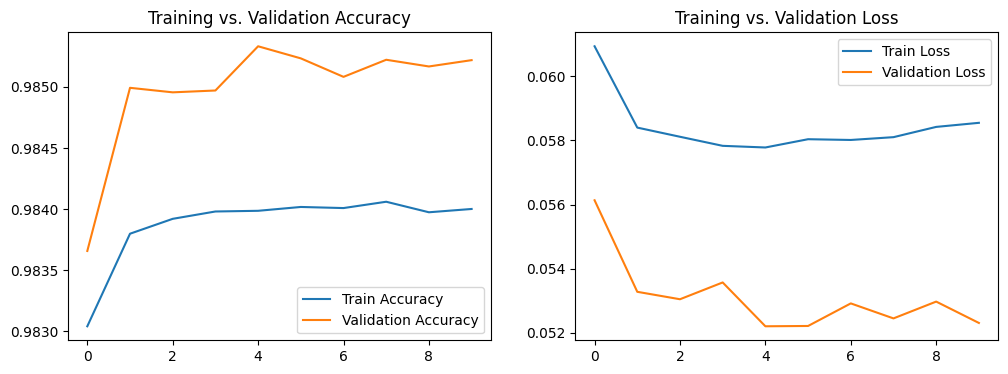

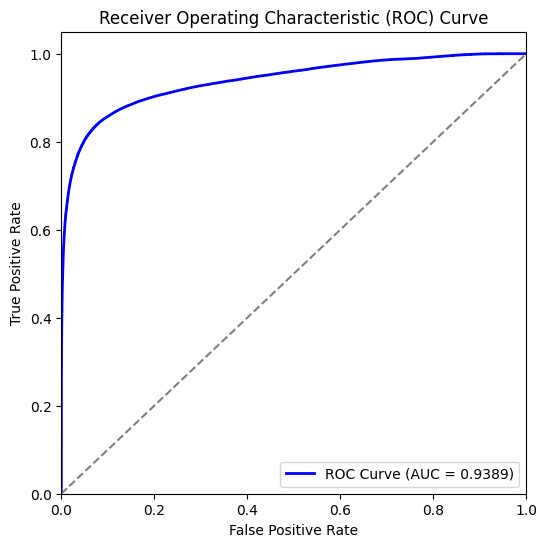

In [ ]:
import os
import numpy as np
import mne
import tensorflow as tf
from scipy.signal import butter, filtfilt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
import warnings

# Suppress RuntimeWarning about duplicate channel names
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Channel names are not unique")

# Define paths
data_root = r"C:\sem 2 thejan\Paper\edf\seizure file"
summary_file = os.path.join(data_root, "all_summaries.txt")

# Butterworth Bandpass Filter
def butter_bandpass_filter(data, lowcut=0.5, highcut=50.0, fs=256, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=1)

# Parse seizure information
def parse_summary(file_path):
    seizure_info = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    file_name = None
    for line in lines:
        line = line.strip()
        if line.startswith("File Name:"):
            file_name = line.split()[-1]
            seizure_info[file_name] = []
        if line.startswith("Seizure Start Time:"):
            start_time = int(line.split()[-2])
        if line.startswith("Seizure End Time:"):
            end_time = int(line.split()[-2])
            seizure_info[file_name].append((start_time, end_time))
    return seizure_info

seizure_info = parse_summary(summary_file)

X, y = [], []  # Data and labels

# Identify the most common 23 channels across all files
channel_counts = {}
for patient in os.listdir(data_root):
    patient_path = os.path.join(data_root, patient)
    if not os.path.isdir(patient_path):
        continue
    files = [f for f in os.listdir(patient_path) if f.endswith('.edf')]
    
    for file in files:
        file_path = os.path.join(patient_path, file)
        raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
        for ch in raw.ch_names:
            channel_counts[ch] = channel_counts.get(ch, 0) + 1

# Select the 23 most common channels
sorted_channels = sorted(channel_counts, key=channel_counts.get, reverse=True)
standard_channels = sorted_channels[:23]

# Process EEG data
for patient in os.listdir(data_root):
    patient_path = os.path.join(data_root, patient)
    if not os.path.isdir(patient_path):
        continue
    files = [f for f in os.listdir(patient_path) if f.endswith('.edf')]
    
    for file in files:
        file_path = os.path.join(patient_path, file)
        raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
        
        # Drop duplicate channels (keep only the first occurrence of each channel)
        unique_ch_names = []
        ch_indices_to_keep = []
        for i, ch_name in enumerate(raw.ch_names):
            if ch_name not in unique_ch_names:
                unique_ch_names.append(ch_name)
                ch_indices_to_keep.append(i)
        
        # Keep only the unique channels
        raw.pick_channels([raw.ch_names[i] for i in ch_indices_to_keep])
        
        # Adjust channels: Keep only the most common 23 channels
        available_channels = [ch for ch in raw.ch_names if ch in standard_channels]
        raw.pick_channels(available_channels, ordered=True, verbose=False)
        
        data, times = raw[:]
        fs = int(raw.info['sfreq'])  # Sampling frequency
        
        # Apply Butterworth Filter
        data = butter_bandpass_filter(data, fs=fs)
        
        # Create seizure and normal samples
        if file in seizure_info and seizure_info[file]:
            for start, end in seizure_info[file]:
                seizure_samples = data[:, start * fs: end * fs]
                normal_samples = data[:, :start * fs]  # Non-seizure samples
                
                X.append(seizure_samples.T)
                y.append(np.ones(len(seizure_samples.T)))  # Label as seizure
                
                X.append(normal_samples.T)
                y.append(np.zeros(len(normal_samples.T)))  # Label as normal

# Convert to numpy arrays
X = np.vstack(X)
y = np.concatenate(y)

# Normalize data
X = (X - np.mean(X)) / np.std(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define ANN Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

# Evaluate model
loss, acc = model.evaluate(X_test, y_test)
y_pred_prob = model.predict(X_test)  # Probability scores for ROC-AUC
y_pred = np.round(y_pred_prob)  # Convert probabilities to binary values

# Compute Metrics
conf_matrix = confusion_matrix(y_test, y_pred)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
precision = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1])
false_positive_rate = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
mcc = matthews_corrcoef(y_test, y_pred)

# ROC-AUC Calculation
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Print Results
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"False Positive Rate (per hr): {false_positive_rate:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"AUC Score: {roc_auc:.4f}")

# Print Confusion Matrix & Classification Report
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Training & Validation Accuracy/Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

C:\Users\Thejan\AppData\Local\Temp\ipykernel_7572\3803900967.py:54: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_7572\3803900967.py:54: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_7572\3803900967.py:54: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_7572\3803900967.py:54: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, prelo

Epoch 1/10


c:\sem 2 thejan\Paper\myenv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


73991/73991 ━━━━━━━━━━━━━━━━━━━━ 98s 1ms/step - accuracy: 0.9763 - loss: 0.0738 - val_accuracy: 0.9827 - val_loss: 0.0522
Epoch 2/10
73991/73991 ━━━━━━━━━━━━━━━━━━━━ 96s 1ms/step - accuracy: 0.9815 - loss: 0.0558 - val_accuracy: 0.9826 - val_loss: 0.0509
Epoch 3/10
73991/73991 ━━━━━━━━━━━━━━━━━━━━ 97s 1ms/step - accuracy: 0.9822 - loss: 0.0538 - val_accuracy: 0.9836 - val_loss: 0.0496
Epoch 4/10
73991/73991 ━━━━━━━━━━━━━━━━━━━━ 96s 1ms/step - accuracy: 0.9826 - loss: 0.0526 - val_accuracy: 0.9834 - val_loss: 0.0494
Epoch 5/10
73991/73991 ━━━━━━━━━━━━━━━━━━━━ 97s 1ms/step - accuracy: 0.9828 - loss: 0.0523 - val_accuracy: 0.9841 - val_loss: 0.0478
Epoch 6/10
73991/73991 ━━━━━━━━━━━━━━━━━━━━ 97s 1ms/step - accuracy: 0.9831 - loss: 0.0515 - val_accuracy: 0.9836 - val_loss: 0.0486
Epoch 7/10
73991/73991 ━━━━━━━━━━━━━━━━━━━━ 96s 1ms/step - accuracy: 0.9833 - loss: 0.0513 - val_accuracy: 0.9831 - val_loss: 0.0496
Epoch 8/10
73991/73991 ━━━━━━━━━━━━━━━━━━━━ 96s 1ms/step - accuracy: 0.9834 - lo

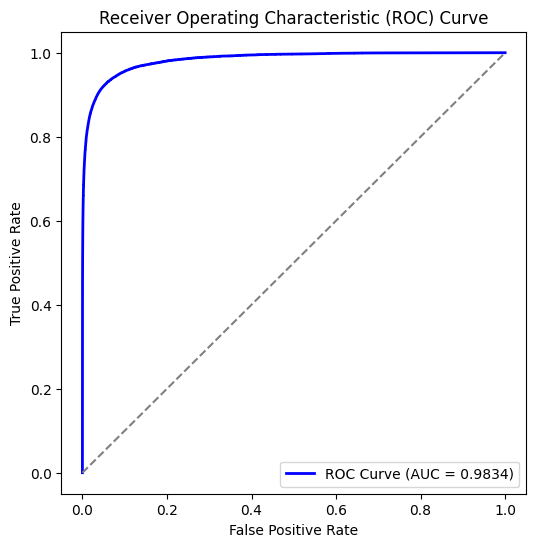

In [4]:
import os
import numpy as np
import mne
import tensorflow as tf
from scipy.signal import butter, filtfilt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
import matplotlib.pyplot as plt

# Define paths
data_root = r"C:\sem 2 thejan\Paper\seizure data\chb01"
summary_file = r"C:\sem 2 thejan\Paper\SUMMARY SEIZURE FOLDER\chb01-summary.txt"

# Butterworth Bandpass Filter
def butter_bandpass_filter(data, lowcut=0.5, highcut=50.0, fs=256, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=1)

# Parse seizure summary file
def parse_summary(file_path):
    seizure_info = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    file_name = None
    for line in lines:
        line = line.strip()
        if line.startswith("File Name:"):
            file_name = line.split()[-1]
            seizure_info[file_name] = []
        if line.startswith("Seizure Start Time:"):
            start_time = int(line.split()[-2])
        if line.startswith("Seizure End Time:"):
            end_time = int(line.split()[-2])
            seizure_info[file_name].append((start_time, end_time))
    return seizure_info

seizure_info = parse_summary(summary_file)

X, y = [], []  # Data and labels

# Process EEG data
for file in seizure_info.keys():
    file_path = os.path.join(data_root, file)
    if not os.path.exists(file_path):
        continue
    
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    data, times = raw[:]
    fs = int(raw.info['sfreq'])  # Sampling frequency
    
    # Apply Butterworth Filter
    data = butter_bandpass_filter(data, fs=fs)
    
    # Extract seizure and non-seizure samples
    for start, end in seizure_info[file]:
        seizure_samples = data[:, start * fs: end * fs]
        normal_samples = data[:, :start * fs]  # Non-seizure samples
        
        X.append(seizure_samples.T)
        y.append(np.ones(len(seizure_samples.T)))  # Label as seizure
        
        X.append(normal_samples.T)
        y.append(np.zeros(len(normal_samples.T)))  # Label as normal

# Convert to numpy arrays
X = np.vstack(X)
y = np.concatenate(y)

# Normalize data
X = (X - np.mean(X)) / np.std(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define ANN Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

# Evaluate model
loss, acc = model.evaluate(X_test, y_test)
y_pred_prob = model.predict(X_test)
y_pred = np.round(y_pred_prob)

# Compute Metrics
conf_matrix = confusion_matrix(y_test, y_pred)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
precision = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1])
false_positive_rate = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
mcc = matthews_corrcoef(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Print Results
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"False Positive Rate (per hr): {false_positive_rate:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"AUC Score: {roc_auc:.4f}")

print("Confusion Matrix:", conf_matrix)
print("Classification Report:", classification_report(y_test, y_pred))

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


C:\Users\Thejan\AppData\Local\Temp\ipykernel_7572\4076058794.py:56: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_7572\4076058794.py:56: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_7572\4076058794.py:56: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\Thejan\AppData\Local\Temp\ipykernel_7572\4076058794.py:56: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, prelo

Epoch 1/10
142324/142324 ━━━━━━━━━━━━━━━━━━━━ 243s 2ms/step - accuracy: 0.8750 - loss: 0.4347 - val_accuracy: 0.9210 - val_loss: 0.1954
Epoch 2/10
142324/142324 ━━━━━━━━━━━━━━━━━━━━ 255s 2ms/step - accuracy: 0.8954 - loss: 0.3774 - val_accuracy: 0.9138 - val_loss: 0.2051
Epoch 3/10
142324/142324 ━━━━━━━━━━━━━━━━━━━━ 295s 2ms/step - accuracy: 0.8981 - loss: 0.3684 - val_accuracy: 0.9226 - val_loss: 0.1864
Epoch 4/10
142324/142324 ━━━━━━━━━━━━━━━━━━━━ 240s 2ms/step - accuracy: 0.8983 - loss: 0.3657 - val_accuracy: 0.9173 - val_loss: 0.1937
Epoch 5/10
142324/142324 ━━━━━━━━━━━━━━━━━━━━ 244s 2ms/step - accuracy: 0.8986 - loss: 0.3632 - val_accuracy: 0.9183 - val_loss: 0.1859
Epoch 6/10
142324/142324 ━━━━━━━━━━━━━━━━━━━━ 209s 1ms/step - accuracy: 0.8994 - loss: 0.3612 - val_accuracy: 0.9198 - val_loss: 0.1833
Epoch 7/10
142324/142324 ━━━━━━━━━━━━━━━━━━━━ 203s 1ms/step - accuracy: 0.8986 - loss: 0.3600 - val_accuracy: 0.9120 - val_loss: 0.2029
Epoch 8/10
142324/142324 ━━━━━━━━━━━━━━━━━━━━ 25

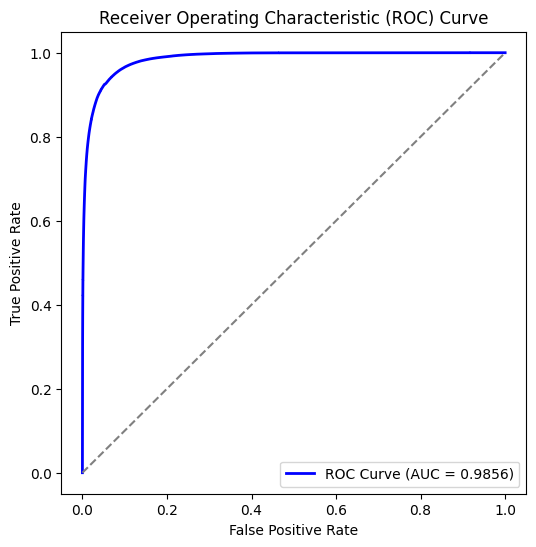

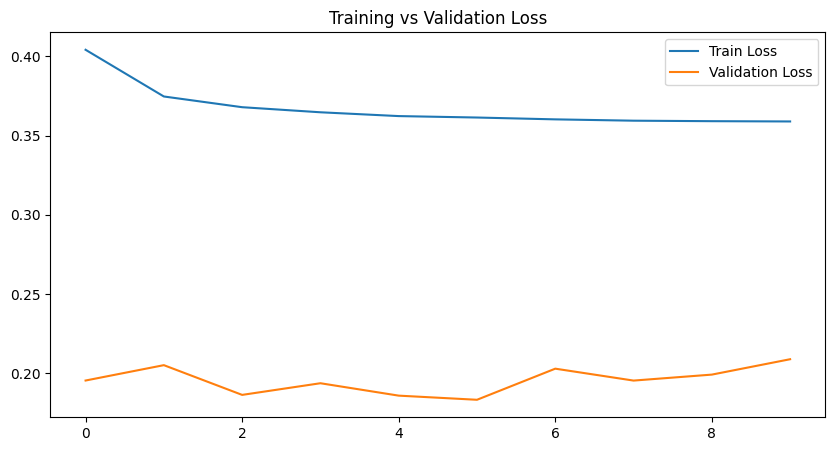

In [ ]:
import os
import numpy as np
import mne
import tensorflow as tf
from scipy.signal import butter, filtfilt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Define paths
data_root = r"C:\sem 2 thejan\Paper\seizure data\chb01"
summary_file = r"C:\sem 2 thejan\Paper\SUMMARY SEIZURE FOLDER\chb01-summary.txt"

# Butterworth Bandpass Filter
def butter_bandpass_filter(data, lowcut=0.5, highcut=50.0, fs=256, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=1)

# Parse seizure summary file
def parse_summary(file_path):
    seizure_info = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    file_name = None
    for line in lines:
        line = line.strip()
        if line.startswith("File Name:"):
            file_name = line.split()[-1]
            seizure_info[file_name] = []
        if line.startswith("Seizure Start Time:"):
            start_time = int(line.split()[-2])
        if line.startswith("Seizure End Time:"):
            end_time = int(line.split()[-2])
            seizure_info[file_name].append((start_time, end_time))
    return seizure_info

seizure_info = parse_summary(summary_file)

X, y = [], []  # Data and labels

# Process EEG data
for file in seizure_info.keys():
    file_path = os.path.join(data_root, file)
    if not os.path.exists(file_path):
        continue
    
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    
    # Ensure unique channel names
    raw.rename_channels({ch: f"{ch}_{i}" for i, ch in enumerate(raw.ch_names) if raw.ch_names.count(ch) > 1})
    
    data, times = raw[:]
    fs = int(raw.info['sfreq'])  # Sampling frequency
    
    # Apply Butterworth Filter
    data = butter_bandpass_filter(data, fs=fs)
    
    # Extract seizure and non-seizure samples
    for start, end in seizure_info[file]:
        seizure_samples = data[:, start * fs: end * fs]
        normal_samples = data[:, :start * fs]  # Non-seizure samples
        
        X.append(seizure_samples.T)
        y.append(np.ones(len(seizure_samples.T)))  # Label as seizure
        
        X.append(normal_samples.T)
        y.append(np.zeros(len(normal_samples.T)))  # Label as normal

# Convert to numpy arrays
X = np.vstack(X)
y = np.concatenate(y)

# Normalize data
X = (X - np.mean(X)) / np.std(X)

# Handle Class Imbalance
sm = SMOTE(random_state=42)
X, y = sm.fit_resample(X, y)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define ANN Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model with class weights
class_weights = {0: 1, 1: 5}  # Give seizures higher weight
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32, class_weight=class_weights)

# Evaluate model
loss, acc = model.evaluate(X_test, y_test)
y_pred_prob = model.predict(X_test)
y_pred = np.round(y_pred_prob)

# Compute Metrics
conf_matrix = confusion_matrix(y_test, y_pred)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
precision = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1])
false_positive_rate = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
mcc = matthews_corrcoef(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Print Results
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"False Positive Rate (per hr): {false_positive_rate:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"AUC Score: {roc_auc:.4f}")

print("Confusion Matrix:", conf_matrix)
print("Classification Report:", classification_report(y_test, y_pred))

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


# Plot Training & Validation Accuracy/Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()


In [1]:
import os
import numpy as np
import mne
import tensorflow as tf
from scipy.signal import butter, filtfilt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from PyEMD import EEMD
import pywt

# **Paths to Data**
data_root = r"C:\sem 2 thejan\Paper\seizure data\chb01"
summary_file = r"C:\sem 2 thejan\Paper\SUMMARY SEIZURE FOLDER\chb01-summary.txt"

# **Butterworth Bandpass Filter**
def butter_bandpass_filter(data, lowcut=0.5, highcut=50.0, fs=256, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=1)

# **Parse seizure summary file**
def parse_summary(file_path):
    seizure_info = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()

    file_name = None
    for line in lines:
        line = line.strip()
        if line.startswith("File Name:"):
            file_name = line.split()[-1]
            seizure_info[file_name] = []
        if line.startswith("Seizure Start Time:"):
            start_time = int(line.split()[-2])
        if line.startswith("Seizure End Time:"):
            end_time = int(line.split()[-2])
            seizure_info[file_name].append((start_time, end_time))
    return seizure_info

seizure_info = parse_summary(summary_file)

# **EEMD for EEG Decomposition**
def apply_eemd(data, max_imf=5):
    eemd = EEMD()
    imfs = []
    for channel in data:
        imf = eemd.eemd(channel)  # Get IMFs
        imfs.append(imf[:max_imf])  # Keep only first few IMFs
    return np.array(imfs)

# **Wavelet Transform for Feature Extraction**
def apply_wavelet(imfs, wavelet='db4', level=3):
    features = []
    for imf in imfs:
        coeffs = pywt.wavedec(imf, wavelet, level=level)  # Wavelet decomposition
        coeffs = np.hstack(coeffs)  # Flatten coefficients
        features.append(coeffs)
    return np.array(features)

X, y = [], []

# **Process EEG Data**
for file in seizure_info.keys():
    file_path = os.path.join(data_root, file)
    if not os.path.exists(file_path):
        continue

    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    
    # **Ensure unique channel names**
    raw.rename_channels({ch: f"{ch}_{i}" for i, ch in enumerate(raw.ch_names) if raw.ch_names.count(ch) > 1})
    
    data, times = raw[:]
    fs = int(raw.info['sfreq'])

    # **Apply Bandpass Filter**
    data = butter_bandpass_filter(data, fs=fs)

    # **Apply EEMD to extract IMFs**
    imfs = apply_eemd(data)

    # **Apply Wavelet Transform on IMFs**
    wavelet_features = apply_wavelet(imfs)

    # **Extract Seizure and Non-Seizure Samples using Wavelet Features**
    for start, end in seizure_info[file]:
        seizure_samples = wavelet_features[:, start * fs: end * fs]
        normal_samples = wavelet_features[:, :start * fs]

        X.append(seizure_samples.T)
        y.append(np.ones(len(seizure_samples.T)))  # Seizure

        X.append(normal_samples.T)
        y.append(np.zeros(len(normal_samples.T)))  # Non-Seizure

# **Convert to NumPy Arrays**
X = np.vstack(X)
y = np.concatenate(y)

# **Normalize Data**
X = (X - np.mean(X)) / np.std(X)

# **Handle Class Imbalance using SMOTE**
sm = SMOTE(random_state=42)
X, y = sm.fit_resample(X, y)

# **Train-Test Split**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Define ANN Model**
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# **Compile Model with Class Weights**
class_weights = {0: 1, 1: 5}  # Higher weight for seizures
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# **Train Model**
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15, batch_size=32, class_weight=class_weights)

# **Evaluate Model**
loss, acc = model.evaluate(X_test, y_test)
y_pred_prob = model.predict(X_test)
y_pred = np.round(y_pred_prob)

# **Compute Metrics**
conf_matrix = confusion_matrix(y_test, y_pred)
sensitivity = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[1, 0])
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
precision = conf_matrix[1, 1] / (conf_matrix[1, 1] + conf_matrix[0, 1])
false_positive_rate = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)
mcc = matthews_corrcoef(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# **Print Results**
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"False Positive Rate (per hr): {false_positive_rate:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"AUC Score: {roc_auc:.4f}")

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_report(y_test, y_pred))

# **Plot ROC Curve**
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Training & Validation Accuracy/Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()

ModuleNotFoundError: No module named 'PyEMD'

In [3]:
pip install PyEMD


Note: you may need to restart the kernel to use updated packages.
